+ This notebook is part of the lecture **GEOMETRIC VIEW OF LINEAR ALGEBRA** in the OCW MIT course 18.06 by Prof Gilbert Strang [1]
+ Created Dr J H Klopper
    + Associate Professor
    + The George Washington University
    + <a href="mailto:juanklopper@gwu.edu">Email me with your thoughts, comments, suggestions and corrections</a> 
<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons Licence" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br /><span xmlns:dct="http://purl.org/dc/terms/" href="http://purl.org/dc/dcmitype/InteractiveResource" property="dct:title" rel="dct:type">Linear Algebra OCW MIT18.06</span> <span xmlns:cc="http://creativecommons.org/ns#" property="cc:attributionName">Jupyter notebook study notes by Dr Juan H Klopper</span> is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

+ [1] <a href="https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/video_galleries/video-lectures/">OCW MIT 18.06</a>

![GWU LOGO](GWU_Logo_Horizontal.png){width=800px}

# Geometric view

## Python packages

We start by importing the necessary Python packages.

In [35]:
# Import the `init_printing` function from the `sympy` package
from sympy import init_printing
# Initialize pretty printing
init_printing()

In [36]:
# Import the `Matrix` class from the `sympy` package
from sympy import Matrix

In [40]:
# Import the `symbols` function from the `sympy` package
from sympy import symbols

In [47]:
# Import the `Eq` class from the `sympy` package
from sympy import Eq

In [ ]:
# Import the numerical Python package `numpy` and alias it as `np`
import numpy as np

In [50]:
# Import the `pyplot` module from the `matplotlib` package and alias it as `plt`
import matplotlib.pyplot as plt

In [51]:
# Set the notebook to produce high-resolution plots
%config InlineBackend.figure_format = 'retina'

## Preamble

The initial exploration of linear algebra is done in the context of linear equations and vectors in two- and three-dimensional space.  This is a geometrical view of linear algebra.

## System of linear equations

Most courses and textbooks introduce linear algebra as a method of solving systems of linear equations.  <span style="color:green"><b>Linear equations</b></span> have variables that are each of power one, do not multiply or divide each other, are not transformed by trigonometric, exponential, and logarithmic functions, and are not part of derivatives, integrals, or any othe roperations.  Examples are shown in (1) below.

$$ \begin{align} {2x}-{y}&={3} \\ -{x} + 2{y} &= {0} \end{align} \tag{1} $$

<span style="color:green"><b>System of linear equations</b></span> or <span style="color:green"><b>linear system</b></span> is a collection of linear equations involving the same set of variables. Solving systems of linear equations attempts at finding numerical solutions for the variables that solve all the equations in the linear system.  A solution to (1) is shown in (2) below.

$$\begin{align}2 &\left( 2 \right) - 1 \left( 1 \right) = 3 \\ - &\left( 2 \right) + 2 \left( 1 \right) = 0\end{align}\tag{2}$$

We note from (2) that $x=2$ and $y=1$. This is the solution to the linear system in (1).  The solution to a linear system is the set of values for the variables that satisfies all the equations in the linear system.  The solution to a linear system is also called a <span style="color:green"><b>root</b></span> or <span style="color:green"><b>solution set</b></span>.

The linear system in (1) can be written as a matrix using only the coefficients of the variables toghether with the constants on the right-hand side of the equations. Such a matrix that includes the right-hand side constants is termed an <span style="color:green"><b>augmented matrix</b></span>.

We can create an augmented matrix from the system in (1).  To do this, we create a matrix of coefficients, including those from both sides of the equations.  We store the matrix as a computer variable called `A_augm` using the `Matrix` function from the `sympy` package, which we import in the code cell below.

In [37]:
# Create a Matrix object that contains the augmented matrix of the system of equations
# and assign it to the variable `A_augm`
A_augm = Matrix([[2, -1, 3], [-1, 2, 0]]) # Note the placement of ()'s and []'s

# Call the `A_augm` variable to display the matrix
A_augm # A_augm is a computer variable that contains the Matrix object

⎡2   -1  3⎤
⎢         ⎥
⎣-1  2   0⎦

With two equations and two unknowns (variables $x$ and $y$), together with the right-hand side constants, we see an array of values along two rows and three columns, written in a set of brackets. Some textbooks use parentheses instead of brackets.

Because `A_augm` was created using the `Matrix()` function from `sympy`, it is an instance of this type.  The `type()` indicates it more specificically as a _mutable, dense matrix_.

In [38]:
# Return the type of object that `A_augm` holds
type(A_augm)  # We see that it is a mutable dense matrix

sympy.matrices.dense.MutableDenseMatrix

Mutable means that we can change the values of the elements (coefficients in this case) and dense because the value of each position in the matrix is stored.  (When there are many zeros, a sparse matrix can be created, that only stores the values that are not zero and their positions.)

We can also create a <span style="color:green"><b>matrix of coefficients</b></span>.  It includes only the left-hand side coefficients and because there are two equations and two unknows, the result is a matrix along two rows and two columns. We state the the shape of the matrix is $2 \times 2$. We create the matrix of coefficients for the linear system in (1) using the `Matrix` function and assign the matrix to the variable `A`.

In [39]:
# Create the matrix of coedfficients and assign it to the variable `A`
A = Matrix([[2, -1], [-1, 2]])  # Matrix of coefficients

# return the matrix of coefficients `A`
A

⎡2   -1⎤
⎢      ⎥
⎣-1  2 ⎦

The variables (unknowns) can be expressed as a column vector, saved as the computer variable `x_vect` below.

We create the mathematical variable $x$ and $y$ and assign them to the computer variable `x` and `y`.

In [41]:
# Create the mathematical variables x and y and assign them to the variables `x` and `y`
x, y = symbols('x y') # Creating symbolic mathematical variables as opposed to computer variables

In the code cell below, we create the column vector of variables $x$ and $y$ and assign it to the variable `x_vect`.  We use the `reshape` method to reshape the vector into a column vector with 2 rows and 1 column. A method is a function that is applied to an object.  In this case, the `reshape` method is applied to the vector created by `Matrix([x, y])`.  The `reshape` method takes two arguments, the number of rows and the number of columns, and reshapes the vector accordingly.

In [44]:
# Create the column vector of variables x and y and assign it to the variable `x_vect`
# Use the `reshape` method to reshape the vector into a column vector with 2 rows and 1 column
x_vect = Matrix([x, y]).reshape(2, 1)

# Return the column vector of variables `x_vect`
x_vect

⎡x⎤
⎢ ⎥
⎣y⎦

The same goes for the column vector, saved as the computer variable `b_vect`.

In [45]:
# Create a column vector with the elements 3 and 0 and assign it to the variable `b_vect`
b_vect = Matrix([3, 0]).reshape(2, 1)

# Return the column vector of solutions `b_vect`
b_vect

⎡3⎤
⎢ ⎥
⎣0⎦

In (3) we see write the linear system problem in matrix form.  The (row, column) sizes are also shown. Note that matrices are ususally written as uppercase letters and that vector are written as lowercase letters in bold-face type.

$$ \begin{align} A_{2 \times 2} \quad \mathbf{x}_{2 \times 1} = \mathbf{b}_{2 \times 1} \\ \\ \begin{bmatrix} 2 && -1 \\ -1 && 2 \end{bmatrix} \begin{bmatrix} x \\ y\end{bmatrix} = \begin{bmatrix} 3 \\ 0 \end{bmatrix} \end{align} \tag{3}$$

Since we created the matrix of coefficients `A` and the vector of unknowns `x_vect`, we can use Python to show the result of this multiplication. The `@` symbol is used for matrix multiplication in Python.  The result is a column vector with two rows and one column, as expected from the matrix multiplication of a $2 \times 2$ matrix and a $2 \times 1$ vector.

In [46]:
# Multiply the matrix of coefficients `A` by the column vector of variables `x_vect` and return the result
A @ x_vect # Matrix multiplication

⎡2⋅x - y ⎤
⎢        ⎥
⎣-x + 2⋅y⎦

The result is the right-hand side of the linear system in (3), that is the vector $\mathbf{b}$.

The `Eq` function in `sympy` is used below to create the matrix times the vector on the left-hand side (resulting in a column vector) and the solution vector on the right.  It gives a visual idea of how we use linear algebra to solve these systems.

In [48]:
Eq(A * x_vect, b_vect) # From Ax = b
# The Eq function takes the arguments left-hand-side (LHS), right-handside (RHS) of the equation

⎡2⋅x - y ⎤   ⎡3⎤
⎢        ⎥ = ⎢ ⎥
⎣-x + 2⋅y⎦   ⎣0⎦

## The row picture

Each linear equation in (1) is an equation of a straight line.  This represents the __row picture__ of a linear system.  The solutions to both equations is at the point where the lines in the plane intersect.  Take a look at the plot below. Don't be too concerned about the code for plotting.  It does not form part of this series of notebooks.

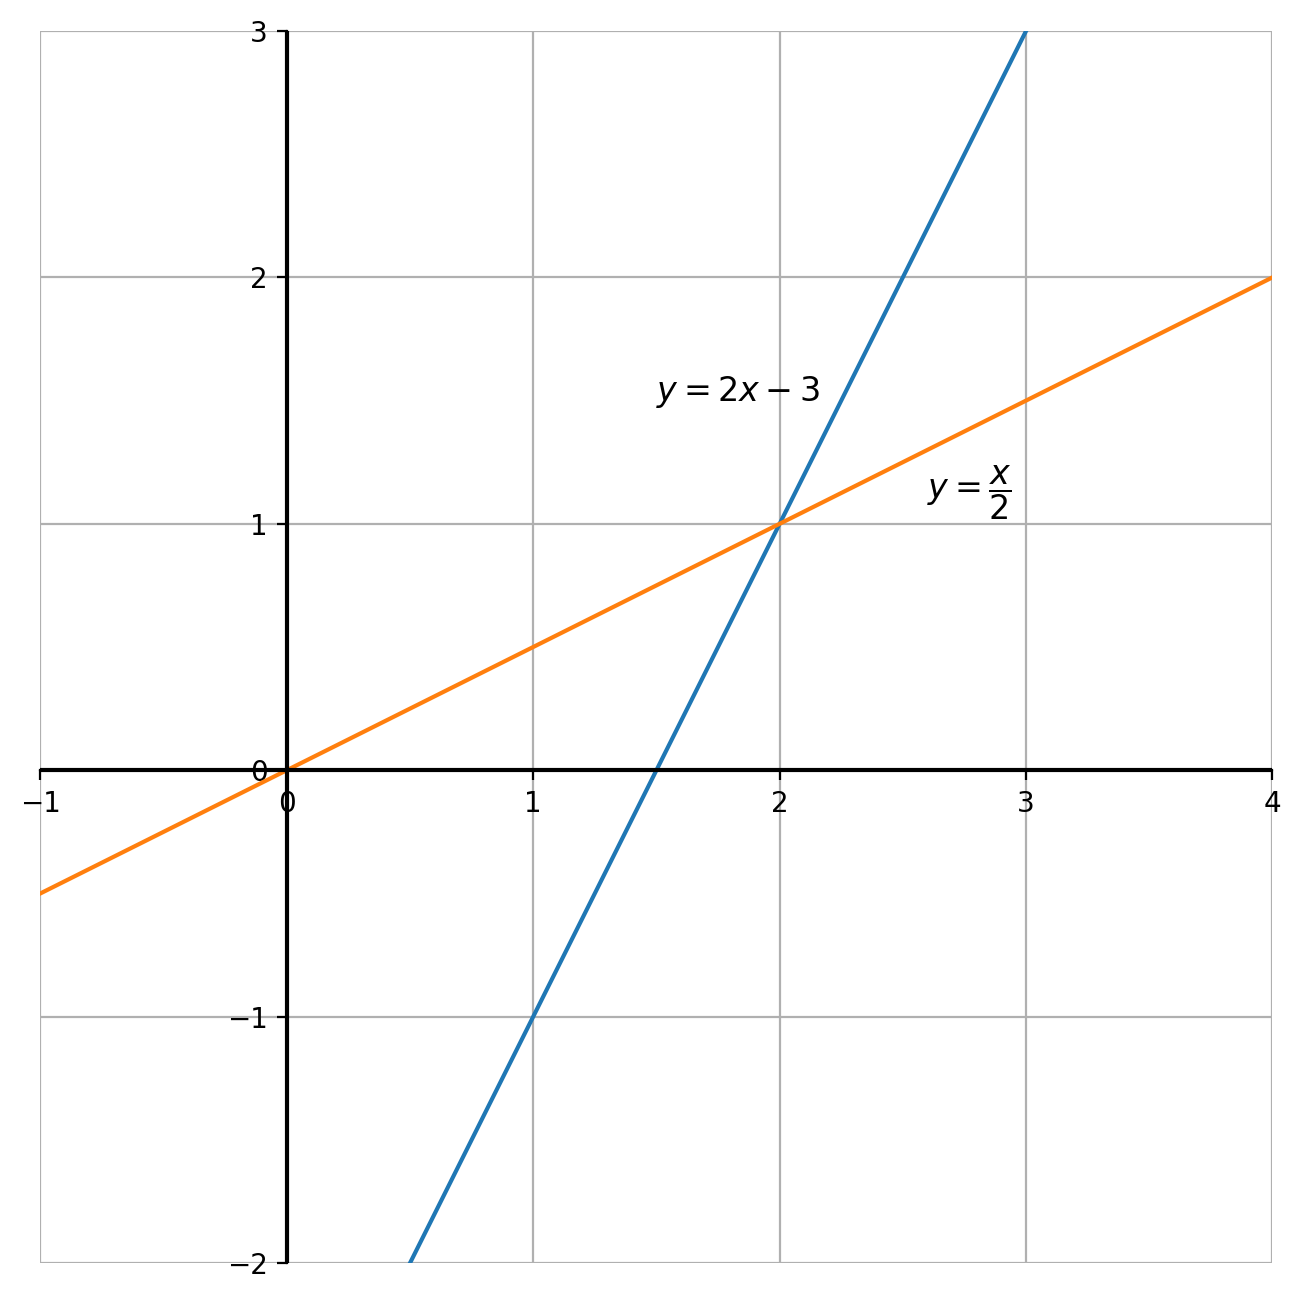

In [52]:
x_vals = np.linspace(-3, 4, 100) # Create 100 values between -3 and 3
# Note that we cannot use the computer variable x, because it has been reserved above as a mathematical variable in
# the symbols function
plt.figure(figsize = (10,8)) # Create a graph of size 10 by 8
plt.plot(x_vals, 2 * x_vals - 3) # Plot every single value created above with 2 times that values
# Taken from the first equation which was y = 2x or f(x) = 2x
# The plot takes the arguments (code between parentheses) of x,y
plt.plot(x_vals, ((x_vals / 2))) # Also plot the second equation
plt.grid(True) # Add a grid to the plot
# Set the x limits to -1 and 3
plt.xlim([-1, 4])
#Set the y limit to -3 to 3
plt.ylim([-2, 3])
# Remove the spines
ax = plt.gca() # Get current axes
ax.set_aspect('equal') # Set equal aspect ratio
ax.spines['top'].set_visible(False) # Remove top spine
ax.spines['right'].set_visible(False) # Remove right spine
ax.spines['bottom'].set_position('zero') # Move bottom spine to zero
ax.spines['left'].set_position('zero') # Move left spine to zero
# Add a horizontal line at y = 0
plt.axhline(y = 0, color = 'k') # Add a horizontal line at y = 0
# Add a vertical line at x = 0
plt.axvline(x = 0, color = 'k') # Add a vertical line at x = 0
# Add the equations to the plot
plt.text(1.5, 1.5, r'$y = 2x - 3$', fontsize = 12) # Add the first equation
plt.text(2.6, 1.1, r'$y = \dfrac{x}{2}$', fontsize = 12) # Add the second equation
plt.show; # Draw the plot on screen

We note that the two line intersect at the point $\left( 2, 1 \right)$.  It should be clear that there are three possible outcomes for a system with two variables and two equations.  Either the lines intersect with a single solution, or they do not intersect at all (parallel lines), with no solutions, or they coincide, with infinitely many solutions.

## The column picture

We can view the same system as a vector problem.  Here the coefficients of each separate variable as a column vector.  This problem now becomes a linear combination of vectors.  We are thus asking how many multiples of one vector plus how many multiples of the other vector will equal the vector on the right hand side.  This should be clear from (4) below.

$$ x\begin{bmatrix} 2 \\ -1 \end{bmatrix}+y\begin{bmatrix} -1 \\ 2 \end{bmatrix}=\begin{bmatrix} 3 \\ 0 \end{bmatrix} \tag{4}$$

As before, we create separate computer variables and show that the end-result is the same.

In [53]:
# Create the column vector of entries 2 and -1 and assign it to the variable `x_var_vect`
x_var_vect = Matrix([2, -1]).reshape(2, 1)

# Call the variable `x_var_vect` to display the column vector
x_var_vect

⎡2 ⎤
⎢  ⎥
⎣-1⎦

In [54]:
# Create the column vector of entries -1 and 2 and assign it to the variable `y_var_vect`
y_var_vect = Matrix([-1, 2]).reshape(2, 1)

# Return the column vector `y_var_vect`
y_var_vect

⎡-1⎤
⎢  ⎥
⎣2 ⎦

Using the `Eq` class, we can show the linear combination of the two vectors on the left-hand side and the solution vector on the right-hand side.  This gives a visual idea of how we use linear algebra to solve these systems.

In [55]:
# Use the `Eq` class to show the linear combination of the two vectors on the left-hand side
# and the solution vector on the right-hand side
Eq(x * x_var_vect + y * y_var_vect, b_vect)

⎡2⋅x - y ⎤   ⎡3⎤
⎢        ⎥ = ⎢ ⎥
⎣-x + 2⋅y⎦   ⎣0⎦

In the image below, we see the two vectors (blue and green) and the resultant vector (orange).

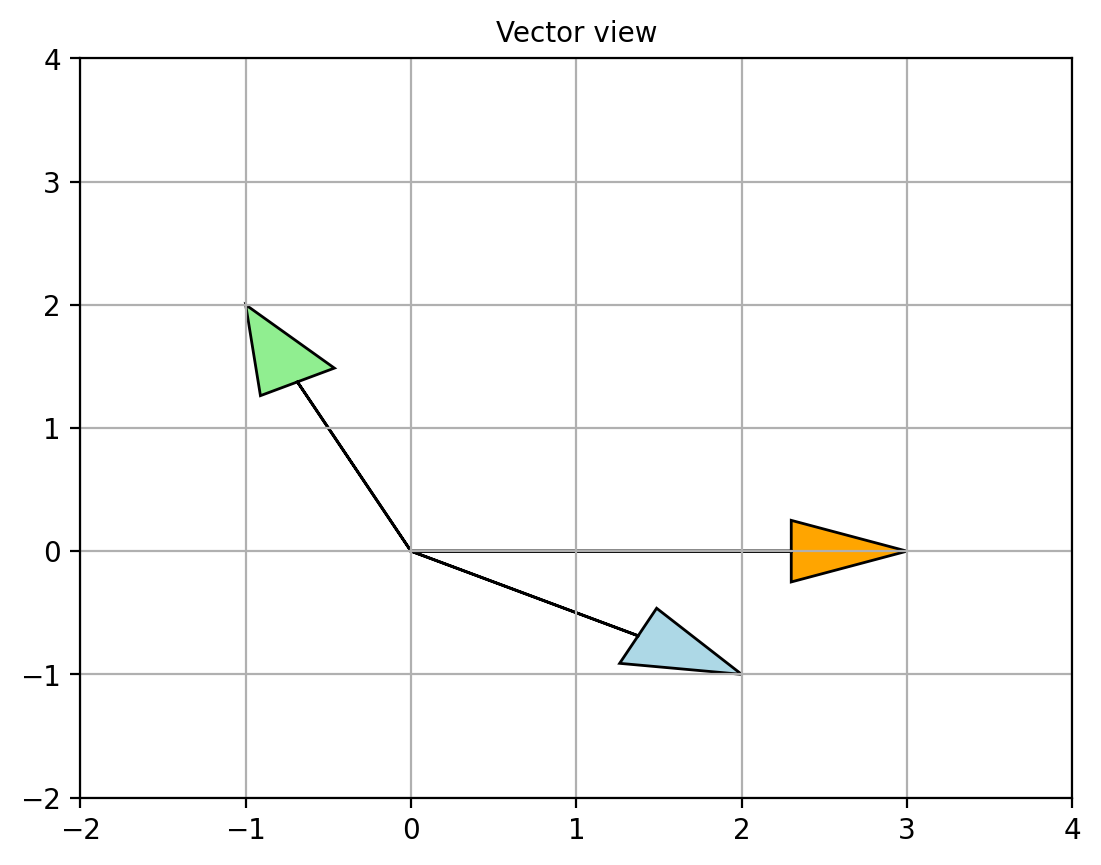

In [56]:
ax = plt.axes()

ax.arrow(0.0, 0.0, 2.0, -1.0,
        length_includes_head=True,
        head_width=0.5,
         head_length=0.7,
         fc='lightblue',
         ec='black')
ax.arrow(0.0, 0.0, -1.0, 2.0,
        length_includes_head=True,
        head_width=0.5,
        head_length=0.7,
        fc='lightgreen',
        ec='black')
ax.arrow(0.0, 0.0, 3.0, 0.0,
        length_includes_head=True,
        head_width=0.5,
         head_length=0.7,
         fc='orange',
         ec='black')

plt.grid()

plt.xlim(-2, 4)
plt.ylim(-2, 4)

plt.title('Vector view',fontsize=10)

plt.show();

We know that it takes twice the blue vector and one times the green vector to give us the orange vector. This is visualized in the plot below, where addition places the tail of the second vector at the head of the first vector, and the resultant vector is drawn from the tail of the first vector to the head of the second vector.  This is a visual representation of how linear combinations of vectors work in linear algebra.

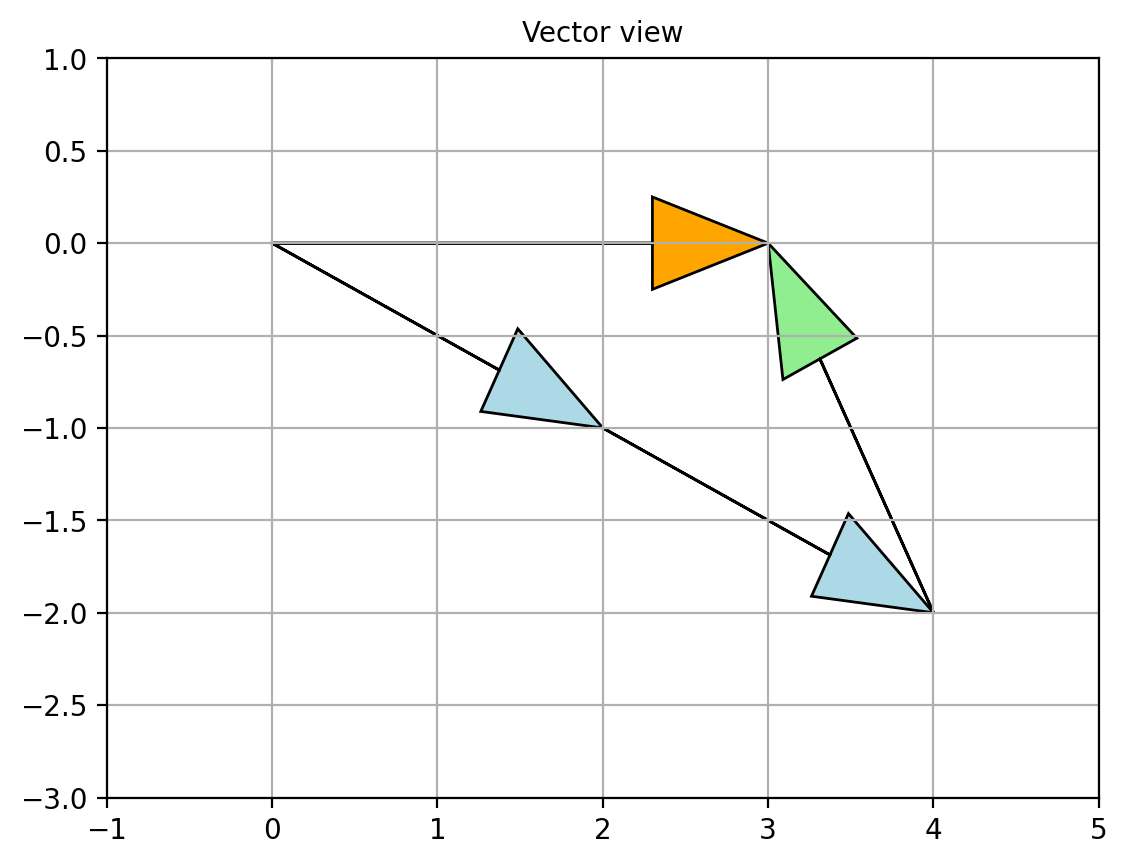

In [61]:
ax = plt.axes()

ax.arrow(0.0, 0.0, 2.0, -1.0,
        length_includes_head=True,
        head_width=0.5,
         head_length=0.7,
         fc='lightblue',
         ec='black')
ax.arrow(2.0, -1.0, 2.0, -1.0,
        length_includes_head=True,
        head_width=0.5,
         head_length=0.7,
         fc='lightblue',
         ec='black')

ax.arrow(4.0, -2.0, -1.0, 2.0,
        length_includes_head=True,
        head_width=0.5,
        head_length=0.7,
        fc='lightgreen',
        ec='black')
ax.arrow(0.0, 0.0, 3.0, 0.0,
        length_includes_head=True,
        head_width=0.5,
         head_length=0.7,
         fc='orange',
         ec='black')

plt.grid()

plt.xlim(-1, 5)
plt.ylim(-3, 1)

plt.title('Vector view',fontsize=10)

plt.show();

It should be very clear that the two vectors are special in that linear combinations of them will allow us to fill a plane in $\mathbb{R}^{2}$ (in which they both lie).

It should also be clear to see that these two vectors are not linear combinations of each other.  If this were so, they are linearly independent and linear combinations of them fill only a line in $\mathbb{R}$. 

We can imagine that the $xy$-plane is filled with (all the points are created by) vectors, i.e. I can find any coordinate by drawing a vector to it.  All these vectors together can be called a _set_ and they fill $\mathbb{R}^{2}$.  Later we will learn about _basis vectors_ and how they _span_ a space.

## The 3-space picture

To end this section, we take a look at the three equation with three variables.

$$ \begin{align} {3x}+{2y}-{z}&=2 \\ {x}-{2y}-{z}&=3 \\ {2x}+{y}-{z}&={1} \end{align} \tag{5}$$

We can create an augmented matrix from the coefficents, stored in the computer variable `A_augm` below.

In [19]:
A_augm = Matrix([[3, 2, -1, 2], [1, -2, -1, 3], [2, 1, -1, 1]])
A_augm

Matrix([
[3,  2, -1, 2],
[1, -2, -1, 3],
[2,  1, -1, 1]])

The `.rref()` method will quickly solve the linear system for use.

In [20]:
A_augm.rref()

(Matrix([
 [1, 0, 0,  5/2],
 [0, 1, 0, -3/2],
 [0, 0, 1,  5/2]]),
 (0, 1, 2))

The solution is where three planes in $\mathbb{R}^{3}$ _cross_.  We can once again imagine that the planes (each equation) may never cross or lie on-top of each other.  Below is an image of three planes crossing at one point.

In [21]:
from sympy.plotting import plot3d

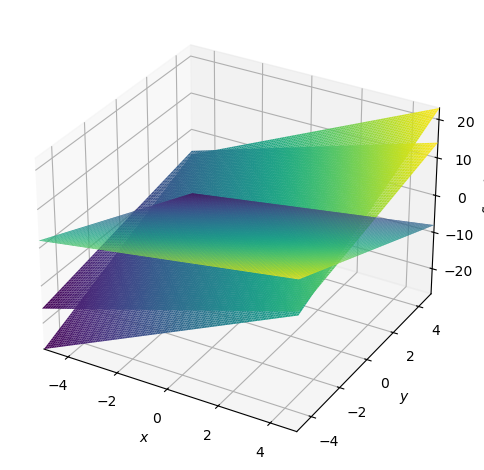

In [22]:
plot3d((3*x+2*y-2, (x,-5,5), (y,-5,5)),
      (x-2*y-3, (x,-5,5), (y,-5,5)),
      (2*x+y-1, (x,-5,5), (y,-5,5)));

As before, we can view this problem as a column picture.

## Conclusion

We have seen how linear systems can be viewed as rows or columns and how they can be seen as matrices and vectors.